# Juros Simples e Compostos com Python

Juros são a remuneração pelo uso do capital ao longo do tempo, o "preço do dinheiro". Esse conceito é a pedra angular de toda a matemática financeira e está presente em praticamente todas as operações do mercado: empréstimos, financiamentos, investimentos em renda fixa, precificação de títulos, análise de crédito e avaliação de projetos. Compreender a diferença entre os regimes de capitalização simples e composta, e saber converter taxas entre diferentes periodicidades, é o ponto de partida obrigatório para qualquer profissional de finanças, contabilidade ou ciência de dados aplicada ao setor financeiro.

## Autoria

Wellington M. Santos - Cientista de Dados  
**LinkedIn**: [in/wellington-moreira-santos](https://linkedin.com/in/wellington-moreira-santos)  
**GitHub**: [/esscova](https://www.github.com/esscova)  
**Email**: [wsantos08@hotmail.com](mailto:wsantos08@hotmail.com)

## Objetivos

Este notebook tem dois propósitos complementares:

1. **Aprendizado:** apresentar de forma rigorosa e progressiva os fundamentos dos regimes de capitalização simples e composta, com fórmulas, intuição econômica e implementação em Python usando `numpy`, `numpy-financial`, `pandas`, `matplotlib` e `plotly`.
    
2. **Portfólio:** demonstrar capacidade de traduzir conceitos de matemática financeira e ciências contábeis em código Python limpo, bem documentado e com visualizações profissionais, habilidade em posições de Data Science, FP&A, BI financeiro e análise de crédito.

## Conteúdo

1. Configuração do Ambiente
2. Juros Simples
    - 2.1 Conceito e fórmula
    - 2.2 Implementação e tabela de evolução
3. Juros Compostos
    - 3.1 Conceito e fórmula
    - 3.2 Implementação e tabela de evolução
4. Comparação: Simples vs. Compostos
    - 4.1 Tabela comparativa com Pandas
    - 4.2 Visualização com Matplotlib
    - 4.3 Visualização interativa com Plotly
5. Taxas de Juros
    - 5.1 Taxa nominal vs. taxa efetiva
    - 5.2 Taxas equivalentes (regime composto)
    - 5.3 Taxas proporcionais (regime simples)
    - 5.4 Conversões com `numpy-financial`
6. Capitalização Contínua
7. Desconto Bancário
    - 7.1 Desconto comercial (por fora)
    - 7.2 Desconto racional (por dentro)
8. Regra dos 72 e Tempo para Dobrar o Capital
9. Exercícios Resolvidos
10. Resumo e Próximos Passos

## 1. CONFIGURAÇÃO DO AMBIENTE

In [1]:
# bibliotecas
import sys
import numpy as np
import numpy_financial as npf
import pandas as pd

# dataviz
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

In [2]:
# configurações
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

pd.options.display.float_format = "R$ {:,.2f}".format

# versoes
print('=== Ambiente configurado ===')
print(f'python: {sys.version.split()[0]}')
print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')
print(f'numpy-financial: {npf.__version__}')
print(f'matplotlib: {matplotlib.__version__}')
print(f'plotly: {plotly.__version__}')
print(f'seaborn: {sns.__version__}')

=== Ambiente configurado ===
python: 3.11.15
pandas: 3.0.2
numpy: 2.4.3
numpy-financial: 1.0.0
matplotlib: 3.10.8
plotly: 6.6.0
seaborn: 0.13.2


## 2. JUROS SIMPLES

### 2.1. Conceito e Fórmula
No **regime de capitalização simples**, os juros incidem sempre sobre o capital inicial (principal). Isso significa que os juros de cada período são constantes e **não se acumulam** sobre si mesmos, não há "juros sobre juros".

**Fórmula:**

$$M = PV \cdot (1 + i \cdot n)$$

Onde:

- $M$ = Montante final
- $PV$ = Valor presente (capital inicial)
- $i$ = Taxa de juros por período
- $n$ = Número de períodos
- $J = M - PV$ = Juros totais

> **Aplicação real:** desconto de duplicatas, cheque especial para poucos dias, operações de curtíssimo prazo no mercado financeiro brasileiro.

### 2.2. Implementação e Tabela Evolução

In [3]:
def juros_simples(pv:float, taxa:float, n:int) -> pd.DataFrame:
    """
    Calcula a evolução do montante no regime de juros simples.

    Args:
        pv  : Capital Inicial (Valor Presente)
        taxa: Taxa de juros por período (decimal)
        n   : Número de períodos

    Returs:
        DataFrame com evolução período a período.
    """

    periodos  = range(0, n+1)
    montantes = [pv * (1 + taxa * t) for t in periodos]
    juros     = [pv * taxa * t for t in periodos]

    return pd.DataFrame({
        'Período' : periodos,
        'Juros'   : juros,
        'Montante': montantes,
    })

**Como seria a evolução de R$ 10.000,00 aplicados com taxas de 2% a.m. durante 12 meses?**

In [4]:
# parametros
PV   = 10_000   # R$ 10.000,00
TAXA = 0.02     # 2% ao mês
N    = 12       # 12 meses

# calculos
montante_final_juros_simples = PV * (1 + TAXA * N)
total_juros_simples = montante_final_juros_simples - PV

# resultado
print(f'Capital Inicial: R$ {PV:.2f}')
print(f'Taxa: {TAXA:.2%}')
print(f'Prazo: {N} meses')
print(f'Juros totais: R$ {total_juros_simples:.2f}')
print(f'Montante final: R$ {montante_final_juros_simples:.2f}')

Capital Inicial: R$ 10000.00
Taxa: 2.00%
Prazo: 12 meses
Juros totais: R$ 2400.00
Montante final: R$ 12400.00


In [5]:
# tabela de evolução 
df_js = juros_simples(PV, TAXA, N)
df_js.set_index('Período')

,Juros,Montante
Período,,
0,R$ 0.00,"R$ 10,000.00"
1,R$ 200.00,"R$ 10,200.00"
2,R$ 400.00,"R$ 10,400.00"
3,R$ 600.00,"R$ 10,600.00"
4,R$ 800.00,"R$ 10,800.00"
5,"R$ 1,000.00","R$ 11,000.00"
6,"R$ 1,200.00","R$ 11,200.00"
7,"R$ 1,400.00","R$ 11,400.00"
8,"R$ 1,600.00","R$ 11,600.00"


## 3. JUROS COMPOSTOS

### 3.1. Conceito e Fórmula

No **regime de capitalização composta**, os juros de cada período são incorporados ao principal e passam a render juros nos períodos seguintes — é o efeito dos "juros sobre juros". A curva de crescimento é exponencial.

**Fórmula:**

$$M = PV \cdot (1 + i)^n$$

> **Aplicação real:** poupança, CDB, Tesouro Direto, financiamentos imobiliários, cartão de crédito, precificação de títulos de renda fixa, análise de projetos (VPL/TIR). É o regime dominante no mercado financeiro.

### 3.2. Implementação

In [6]:
def juros_compostos(pv:float, taxa:float, n:int) -> pd.DataFrame:
    """
    Calcula a evolução do montante no regime de juros compostos.

    Args
        pv (float)   : Capital Inicial (Valor Presente)
        taxa (float) : Taxa de juros por período
        n (int)      : Número de períodos
    
    Returns
        DataFrame com evolução período a período
    """

    periodos  = range(0, n+1)
    montantes = [pv * (1 + taxa) ** t for t in periodos]
    juros     = [m - pv for m in montantes]

    return pd.DataFrame({
        'Período':periodos,
        'Juros':juros,
        'Montante':montantes,
    })

**Agora vemos o montante final com juros compostos**

In [7]:
# calculos
montante_final_juros_compostos = PV * (1 + TAXA) ** N # lembrando 10.000 aplicados a 2% a.m. por 12 meses
total_juros_compostos          = montante_final_juros_compostos - PV

# resultado
print(f'Capital Inicial: R$ {PV:.2f}')
print(f'Taxa: {TAXA:.2%}')
print(f'Prazo: {N} meses')
print(f'Juros totais: R$ {total_juros_compostos:.2f}')
print(f'Montante final: R$ {montante_final_juros_compostos:.2f}')

Capital Inicial: R$ 10000.00
Taxa: 2.00%
Prazo: 12 meses
Juros totais: R$ 2682.42
Montante final: R$ 12682.42


In [8]:
# tabela de evolução
df_jc = juros_compostos(PV, TAXA, N)
df_jc.set_index('Período')

,Juros,Montante
Período,,
0,R$ 0.00,"R$ 10,000.00"
1,R$ 200.00,"R$ 10,200.00"
2,R$ 404.00,"R$ 10,404.00"
3,R$ 612.08,"R$ 10,612.08"
4,R$ 824.32,"R$ 10,824.32"
5,"R$ 1,040.81","R$ 11,040.81"
6,"R$ 1,261.62","R$ 11,261.62"
7,"R$ 1,486.86","R$ 11,486.86"
8,"R$ 1,716.59","R$ 11,716.59"


## 4. COMPARAÇÃO: SIMPLES Vs. COMPOSTOS
### 4.1. Tabela Comparativa

In [9]:
df_comp = pd.DataFrame({
    'Período'           : df_js['Período'],
    'Montante Simples'  : df_js['Montante'],
    'Montante Composto' : df_jc['Montante'],
})
df_comp['Diferença'] = df_comp['Montante Composto'] - df_comp['Montante Simples']
df_comp.set_index('Período')

,Montante Simples,Montante Composto,Diferença
Período,,,
0,"R$ 10,000.00","R$ 10,000.00",R$ 0.00
1,"R$ 10,200.00","R$ 10,200.00",R$ 0.00
2,"R$ 10,400.00","R$ 10,404.00",R$ 4.00
3,"R$ 10,600.00","R$ 10,612.08",R$ 12.08
4,"R$ 10,800.00","R$ 10,824.32",R$ 24.32
5,"R$ 11,000.00","R$ 11,040.81",R$ 40.81
6,"R$ 11,200.00","R$ 11,261.62",R$ 61.62
7,"R$ 11,400.00","R$ 11,486.86",R$ 86.86
8,"R$ 11,600.00","R$ 11,716.59",R$ 116.59


> **Observação contábil:** No primeiro período, simples e compostos produzem o mesmo resultado. A divergência cresce de forma acelerada com o tempo, quanto maior o prazo, maior a vantagem dos juros compostos para o credor (ou o custo para o devedor).

### 4.2. Visualização com Matplotlib

In [22]:
# cores
BLUE='#4c72b0'
GREEN='#55a868'
ORANGE='#dd8452'

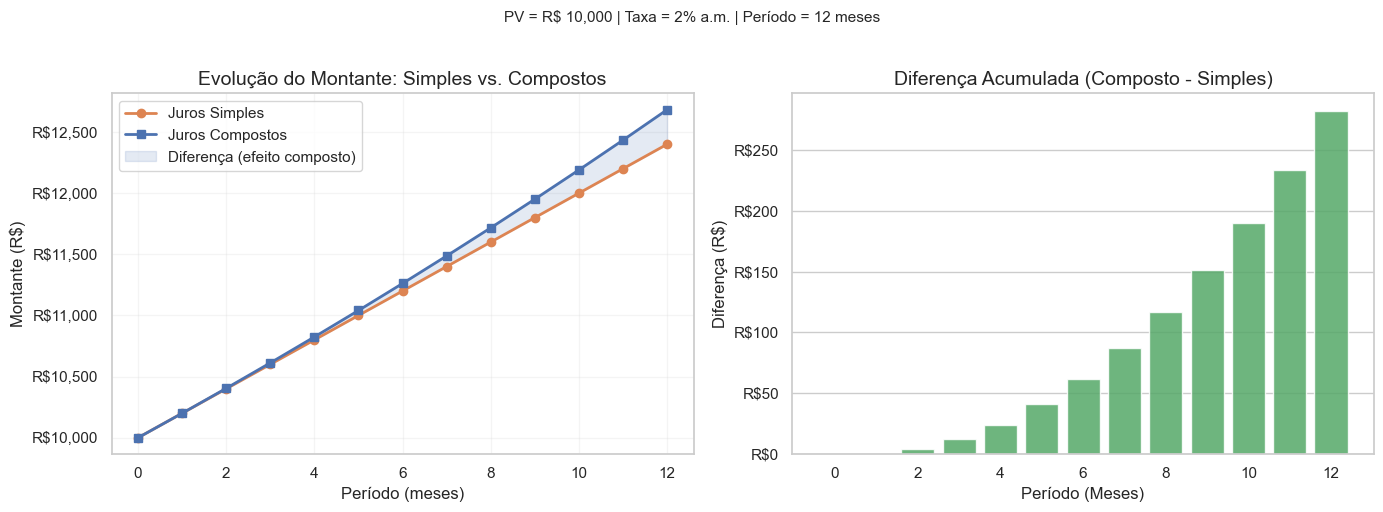

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
periodos = df_comp['Período'].values

# evolucao montante
axes[0].plot(periodos, df_comp['Montante Simples'], 'o-', label='Juros Simples', color=ORANGE, linewidth=2)
axes[0].plot(periodos, df_comp['Montante Composto'], 's-', label='Juros Compostos', color=BLUE, linewidth=2)
axes[0].fill_between(
    periodos,
    df_comp['Montante Simples'],
    df_comp['Montante Composto'],
    alpha=.15,
    color=BLUE,
    label='Diferença (efeito composto)'
)
axes[0].set_title('Evolução do Montante: Simples vs. Compostos')
axes[0].set_xlabel('Período (meses)')
axes[0].set_ylabel('Montante (R$)')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _:f'R${x:,.0f}')
)
axes[0].grid(alpha=.2)
axes[0].legend()

# diff acumulada
axes[1].bar(periodos, df_comp['Diferença'], color=GREEN, alpha=.85, edgecolor='white')
axes[1].set_title('Diferença Acumulada (Composto - Simples)')
axes[1].set_xlabel('Período (Meses)')
axes[1].set_ylabel('Diferença (R$)')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _:f'R${x:,.0f}')
)
axes[1].grid(axis='x')


plt.suptitle(f'PV = R$ {PV:,.0f} | Taxa = {TAXA:.0%} a.m. | Período = {N} meses',
            fontsize=11,
            y=1.02)
plt.tight_layout()
plt.show()

### 4.3. Visualização Interativa com Plotly

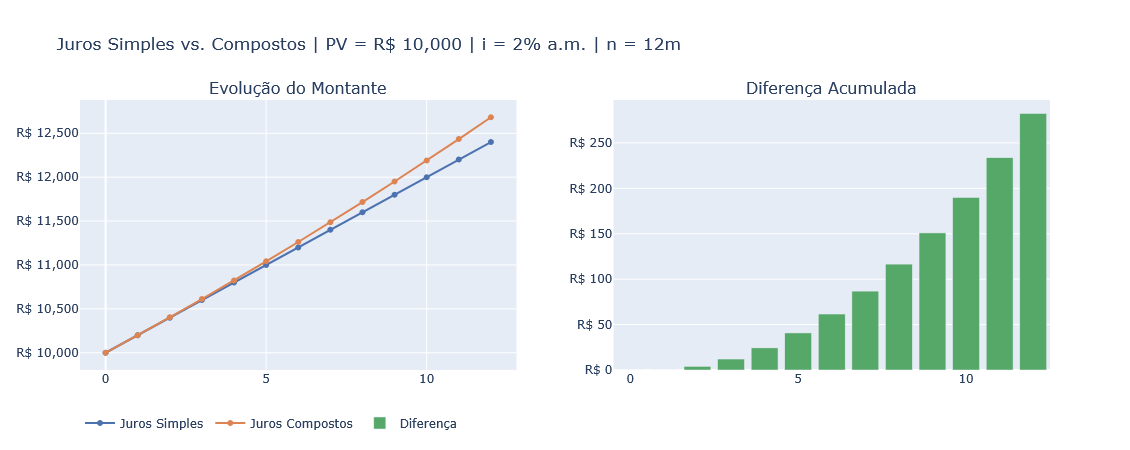

In [37]:
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=('Evolução do Montante', 
                    'Diferença Acumulada')
)

# evolucao montante
## juros simples
fig.add_trace( 
    go.Scatter(x=periodos,
               y=df_comp['Montante Simples'],
               mode='lines+markers',
               name='Juros Simples',
               line=dict(color=BLUE, width=2),
               hovertemplate='Período %{x}<br>Montante: R$ %{y:,.2f}<extra>Simples</extra>' 
              ),
    row=1, col=1
)
## juros compostos
fig.add_trace(
    go.Scatter(x=periodos,
               y=df_comp['Montante Composto'],
               mode='lines+markers',
               name='Juros Compostos',
               line=dict(color=ORANGE, width=2),
               hovertemplate='Período %{x}<br>Diferença: R$ %{y:,.2f}<extra>Compostos</extra>'
              ),
    row=1, col=1
)

# diff
fig.add_trace(
    go.Bar(x=periodos,
           y=df_comp['Diferença'],
           name='Diferença',
           marker_color=GREEN,
           hovertemplate='Período %{x}<br>Diferença: R$ %{y:,.2f}<extra></extra>'
          ),

    row=1, col=2
)

fig.update_layout(
    title=f'Juros Simples vs. Compostos | PV = R$ {PV:,.0f} | i = {TAXA:.0%} a.m. | n = {N}m',
    hovermode='x unified',
    height=450,
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=-.25
    )
)

fig.update_yaxes(tickprefix='R$ ', tickformat=',.0f')
fig.update_layout

fig.show()

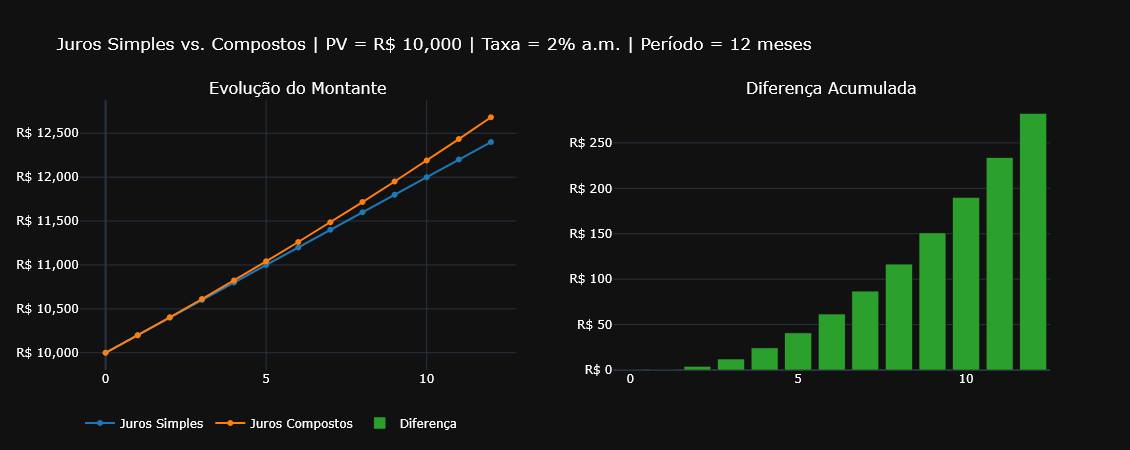

In [40]:
BLUE = '#1f77b4'
ORANGE = '#ff7f0e'
GREEN = '#2ca02c'

# subplots
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=('Evolução do Montante', 'Diferença Acumulada')
)

# evolução do montante
fig.add_trace(
    go.Scatter(
        x=periodos,
        y=df_comp['Montante Simples'],
        mode='lines+markers',
        name='Juros Simples',
        line=dict(color=BLUE, width=2),
        hovertemplate='Período %{x}<br>Montante: R$ %{y:,.2f}<extra>Simples</extra>'
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=periodos,
        y=df_comp['Montante Composto'],
        mode='lines+markers',
        name='Juros Compostos',
        line=dict(color=ORANGE, width=2),
        hovertemplate='Período %{x}<br>Montante: R$ %{y:,.2f}<extra>Compostos</extra>'
    ),
    row=1, col=1
)

# diferença
fig.add_trace(
    go.Bar(
        x=periodos,
        y=df_comp['Diferença'],
        name='Diferença',
        marker_color=GREEN,
        hovertemplate='Período %{x}<br>Diferença: R$ %{y:,.2f}<extra></extra>'
    ),
    row=1, col=2
)

# layout com tema dark
fig.update_layout(
    title=f'Juros Simples vs. Compostos | PV = R$ {PV:,.0f} | Taxa = {TAXA:.0%} a.m. | Período = {N} meses',
    hovermode='x unified',
    height=450,
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=-0.25
    ),
    template='plotly_dark', 
    font=dict(color='white') 
)

fig.update_yaxes(tickprefix='R$ ', tickformat=',.0f') # up eixos
fig.show()

## 5. DESAFIOS PRÁTICOS

### 5.1. A Descoberta do Capital
Um investidor aplicou uma quantia desconhecida em um título que rende 2% ao mês sob o regime de juros simples. Após um ano de aplicação, ele percebeu que o valor rendido apenas de juros foi de R$ 240,00.
Seu objetivo é:

    Calcular o capital inicial investido.
    Determinar o montante final (capital + juros) ao término do período.
    Implementar uma função em Python que resolva esse problema para qualquer valor de juro recebido.

## 6. NUMPY FINANCIAL
O numpy-financial é uma biblioteca Python que fornece funções financeiras elementares, semelhantes às encontradas em softwares de planilha como o Excel. Originalmente, essas funções faziam parte do pacote principal do NumPy, mas foram separadas em um módulo independente a partir da versão 1.17. 

Este pacote é focado em juros compostos (como fv, pv, nper). Para juros simples, ele não oferece uma função específica porque a matemática é uma multiplicação direta.